# Laptop Price Prediction
## This project is a prototype developed to predict the price of the laptop using various regression algorithms
### The link of the datset is : https://www.kaggle.com/datasets/jacksondivakarr/

In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('data.csv')
df

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
888,926,1015,Asus,Vivobook 15X 2023 K3504VAB-NJ321WS Laptop,44990,69.323529,13th Gen ‎Intel Core i3 1315U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Integrated Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
889,927,1016,Asus,TUF A15 FA577RM-HQ032WS Laptop,110000,71.000000,6th Gen AMD Ryzen 7 6800H,"Octa Core, 16 Threads",16GB,DDR,1TB,SSD,6GB NVIDIA GeForce RTX 3060,15.6,2560.0,1440.0,Windows 11 OS,1
890,928,1017,Asus,ROG Zephyrus G14 2023 GA402XV-N2034WS Gaming L...,189990,89.000000,7th Gen AMD Ryzen 9 7940HS,"Octa Core, 16 Threads",32GB,DDR5,1TB,SSD,8GB NVIDIA GeForce RTX 4060,14.0,2560.0,1600.0,Windows 11 OS,1
891,929,1018,Asus,TUF Gaming F15 2023 FX507VU-LP083WS Gaming Laptop,129990,73.000000,13th Gen Intel Core i7 13700H,"14 Cores (6P + 8E), 20 Threads",16GB,DDR4,512GB,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,Windows 11 OS,1


In [5]:
df.head()

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
0,0,0,HP,Victus 15-fb0157AX Gaming Laptop,49900,73.000000,5th Gen AMD Ryzen 5 5600H,"Hexa Core, 12 Threads",8GB,DDR4,512GB,SSD,4GB AMD Radeon RX 6500M,15.6,1920.0,1080.0,Windows 11 OS,1
1,1,1,HP,15s-fq5007TU Laptop,39900,60.000000,12th Gen Intel Core i3 1215U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
2,2,2,Acer,One 14 Z8-415 Laptop,26990,69.323529,11th Gen Intel Core i3 1115G4,"Dual Core, 4 Threads",8GB,DDR4,512GB,SSD,Intel Iris Xe Graphics,14.0,1920.0,1080.0,Windows 11 OS,1
3,3,3,Lenovo,Yoga Slim 6 14IAP8 82WU0095IN Laptop,59729,66.000000,12th Gen Intel Core i5 1240P,"12 Cores (4P + 8E), 16 Threads",16GB,LPDDR5,512GB,SSD,Intel Integrated Iris Xe,14.0,2240.0,1400.0,Windows 11 OS,1
4,4,4,Apple,MacBook Air 2020 MGND3HN Laptop,69990,69.323529,Apple M1,Octa Core (4P + 4E),8GB,DDR4,256GB,SSD,Apple M1 Integrated Graphics,13.3,2560.0,1600.0,Mac OS,1


In [6]:
df.tail()

,Unnamed: 0.1,Unnamed: 0,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
888,926,1015,Asus,Vivobook 15X 2023 K3504VAB-NJ321WS Laptop,44990,69.323529,13th Gen ‎Intel Core i3 1315U,"Hexa Core (2P + 4E), 8 Threads",8GB,DDR4,512GB,SSD,Integrated Intel UHD Graphics,15.6,1920.0,1080.0,Windows 11 OS,1
889,927,1016,Asus,TUF A15 FA577RM-HQ032WS Laptop,110000,71.000000,6th Gen AMD Ryzen 7 6800H,"Octa Core, 16 Threads",16GB,DDR,1TB,SSD,6GB NVIDIA GeForce RTX 3060,15.6,2560.0,1440.0,Windows 11 OS,1
890,928,1017,Asus,ROG Zephyrus G14 2023 GA402XV-N2034WS Gaming L...,189990,89.000000,7th Gen AMD Ryzen 9 7940HS,"Octa Core, 16 Threads",32GB,DDR5,1TB,SSD,8GB NVIDIA GeForce RTX 4060,14.0,2560.0,1600.0,Windows 11 OS,1
891,929,1018,Asus,TUF Gaming F15 2023 FX507VU-LP083WS Gaming Laptop,129990,73.000000,13th Gen Intel Core i7 13700H,"14 Cores (6P + 8E), 20 Threads",16GB,DDR4,512GB,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,Windows 11 OS,1
892,930,1019,Asus,TUF Gaming A15 2023 FA577XU-LP041WS Gaming Laptop,131990,84.000000,7th Gen AMD Ryzen 9 7940HS,"Octa Core, 16 Threads",16GB,DDR4,1TB,SSD,6GB NVIDIA GeForce RTX 4050,15.6,1920.0,1080.0,Windows 11 OS,1


In [7]:
df.columns


Index(['Unnamed: 0.1', 'Unnamed: 0', 'brand', 'name', 'price', 'spec_rating',
       'processor', 'CPU', 'Ram', 'Ram_type', 'ROM', 'ROM_type', 'GPU',
       'display_size', 'resolution_width', 'resolution_height', 'OS',
       'warranty'],
      dtype='object')

In [8]:
df.drop(columns=['Unnamed: 0.1','Unnamed: 0'],inplace=True)

In [9]:
df.columns

Index(['brand', 'name', 'price', 'spec_rating', 'processor', 'CPU', 'Ram',
       'Ram_type', 'ROM', 'ROM_type', 'GPU', 'display_size',
       'resolution_width', 'resolution_height', 'OS', 'warranty'],
      dtype='object')

In [10]:
len(df.columns)

16

In [11]:
df.shape

(893, 16)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              893 non-null    object 
 1   name               893 non-null    object 
 2   price              893 non-null    int64  
 3   spec_rating        893 non-null    float64
 4   processor          893 non-null    object 
 5   CPU                893 non-null    object 
 6   Ram                893 non-null    object 
 7   Ram_type           893 non-null    object 
 8   ROM                893 non-null    object 
 9   ROM_type           893 non-null    object 
 10  GPU                893 non-null    object 
 11  display_size       893 non-null    float64
 12  resolution_width   893 non-null    float64
 13  resolution_height  893 non-null    float64
 14  OS                 893 non-null    object 
 15  warranty           893 non-null    int64  
dtypes: float64(4), int64(2), o

In [13]:
df.describe()

,price,spec_rating,display_size,resolution_width,resolution_height,warranty
count,893.000000,893.000000,893.000000,893.000000,893.000000,893.000000
mean,79907.409854,69.379026,15.173751,2035.393057,1218.324748,1.079507
std,60880.043823,5.541555,0.939095,426.076009,326.756883,0.326956
min,9999.000000,60.000000,11.600000,1080.000000,768.000000,0.000000
25%,44500.000000,66.000000,14.000000,1920.000000,1080.000000,1.000000
50%,61990.000000,69.323529,15.600000,1920.000000,1080.000000,1.000000
75%,90990.000000,71.000000,15.600000,1920.000000,1200.000000,1.000000
max,450039.000000,89.000000,18.000000,3840.000000,3456.000000,3.000000


In [14]:
df.isnull().sum()

brand                0
name                 0
price                0
spec_rating          0
processor            0
CPU                  0
Ram                  0
Ram_type             0
ROM                  0
ROM_type             0
GPU                  0
display_size         0
resolution_width     0
resolution_height    0
OS                   0
warranty             0
dtype: int64

In [15]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
888    False
889    False
890    False
891    False
892    False
Length: 893, dtype: bool

In [16]:
# Print unique values and count for each column  
for column in df.columns:  
    unique_values = df[column].unique()  
    num_unique_values = len(unique_values)  
    print(f"Unique values in column '{column}': {unique_values}  (Total unique values: {num_unique_values})\n")  

Unique values in column 'brand': ['HP' 'Acer' 'Lenovo' 'Apple' 'Dell' 'Asus' 'Samsung' 'Ultimus'
 'Primebook' 'MSI' 'Infinix' 'Wings' 'Honor' 'Zebronics' 'Xiaomi' 'iBall'
 'Chuwi' 'Realme' 'Avita' 'Walker' 'Huawei' 'Tecno' 'Gigabyte' 'Vaio'
 'Microsoft' 'Fujitsu' 'LG' 'Ninkear' 'Razer' 'AXL']  (Total unique values: 30)

Unique values in column 'name': ['Victus 15-fb0157AX Gaming Laptop' '15s-fq5007TU Laptop'
 'One 14 Z8-415 Laptop' 'Yoga Slim 6 14IAP8 82WU0095IN Laptop'
 'MacBook Air 2020 MGND3HN Laptop' 'Extensa EX214-53 Laptop'
 'Inspiron 3520 D560896WIN9B Laptop' 'Nitro V ANV15-51 2023 Gaming Laptop'
 'Vivobook 15 X1502ZA-EJ523WS Laptop' 'Galaxy Book2 Pro 13 Laptop'
 'V15 G3 IAP 82TTA08AIN Laptop' 'Pro NU14U3INC43BN-CS Laptop'
 'TUF Gaming F15 2022 FX507ZC4-HN116W Gaming Laptop' '4G Android Laptop'
 'V15 G4 \u200e82YU00W7IN Laptop'
 'TUF Gaming F15 FX506HF-HN024W Gaming Laptop'
 'Modern 14 C11M-031IN Laptop' 'Zerobook 2023 Laptop'
 'Victus 15-fa0666TX Gaming Laptop'
 'IdeaPad Gaming

In [17]:
df.select_dtypes(include=['object']).columns

Index(['brand', 'name', 'processor', 'CPU', 'Ram', 'Ram_type', 'ROM',
       'ROM_type', 'GPU', 'OS'],
      dtype='object')

## Data visualization

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
sns.set_style("whitegrid")

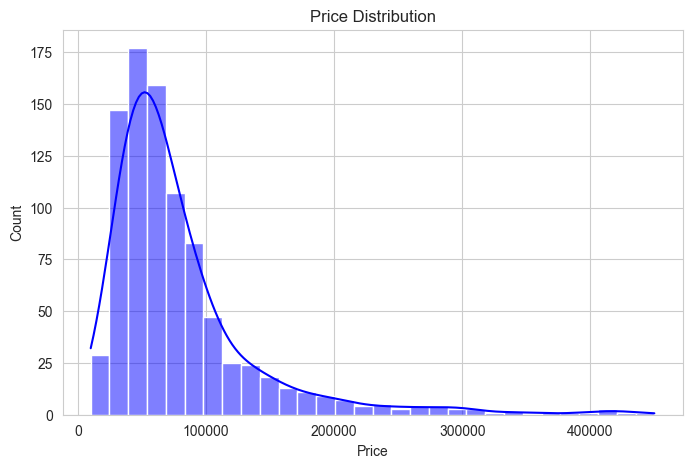

In [20]:
# 1. Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='blue')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

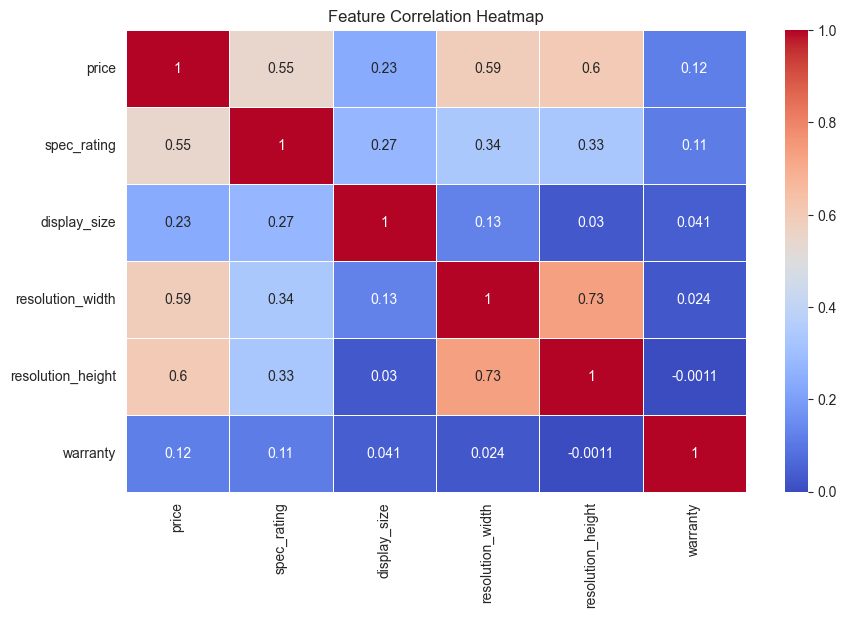

In [21]:
# 2. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


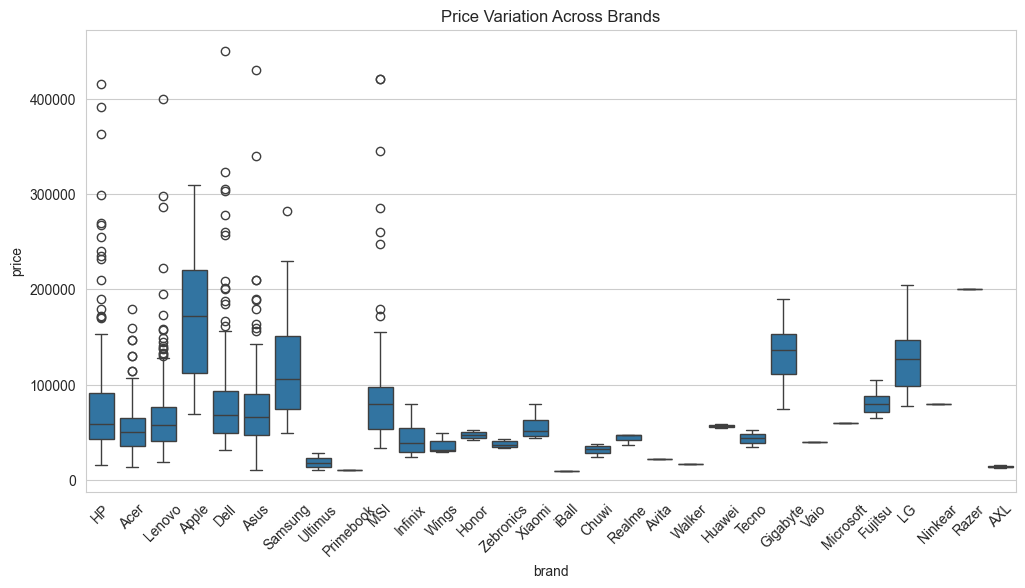

In [22]:
# 3. Boxplot of Price by Brand
plt.figure(figsize=(12,6))
sns.boxplot(x='brand', y='price', data=df)
plt.xticks(rotation=45)
plt.title('Price Variation Across Brands')
plt.show()

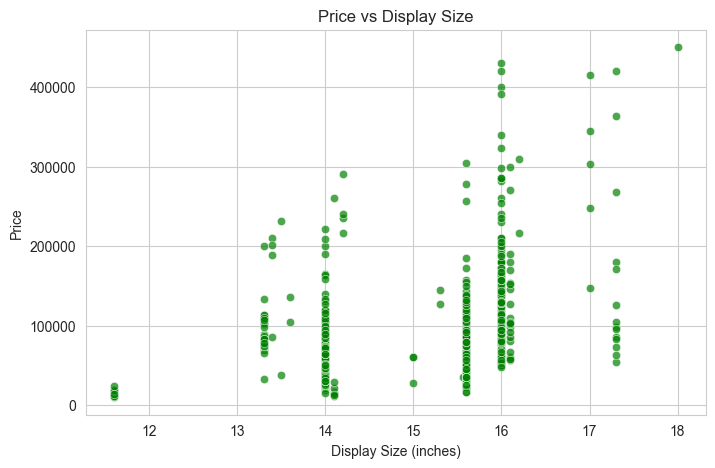

In [23]:
# 3. Scatter Plot (Price vs. Display Size)
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['display_size'], y=df['price'], alpha=0.7, color='green')
plt.title('Price vs Display Size')
plt.xlabel('Display Size (inches)')
plt.ylabel('Price')
plt.show()

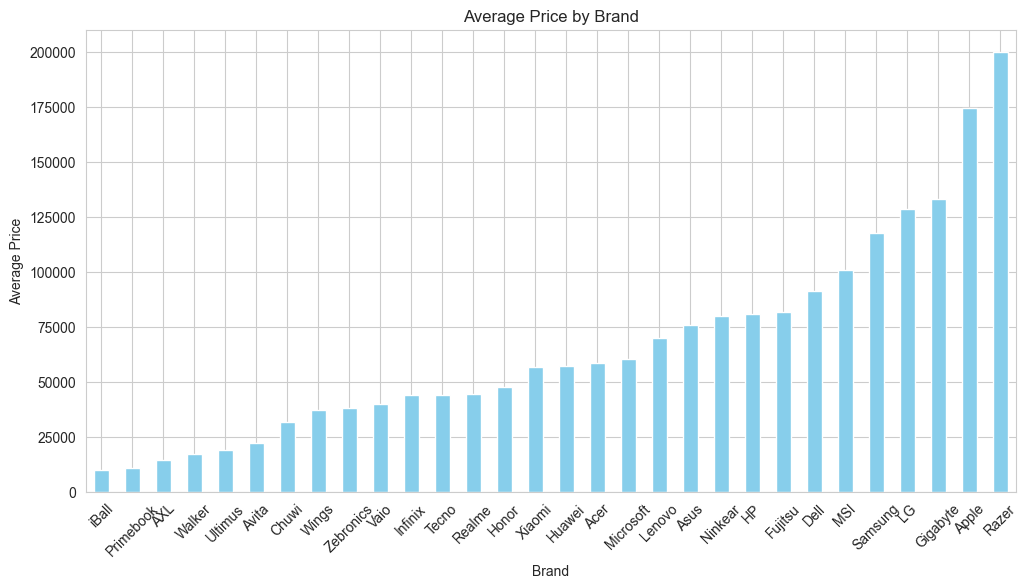

In [24]:
# 2. Average Price by Brand (Bar Chart)
plt.figure(figsize=(12,6))
avg_price_brand = df.groupby('brand')['price'].mean().sort_values()
avg_price_brand.plot(kind='bar', color='skyblue')
plt.title('Average Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

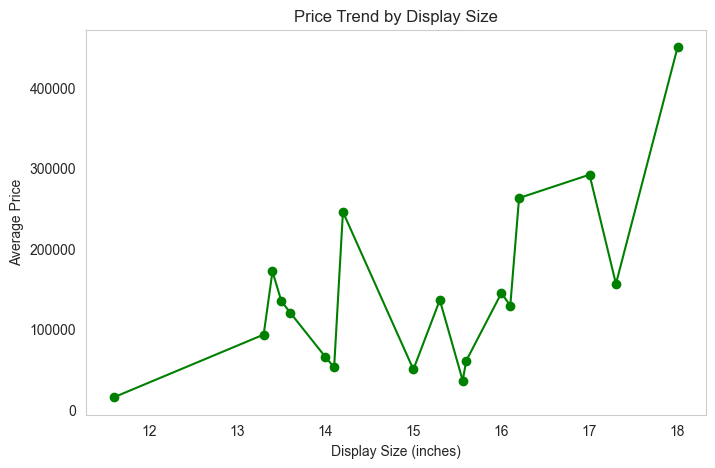

In [25]:
# 3. Price Trend by Display Size (Line Chart)
plt.figure(figsize=(8,5))
display_price = df.groupby('display_size')['price'].mean()
display_price.plot(kind='line', marker='o', color='green')
plt.title('Price Trend by Display Size')
plt.xlabel('Display Size (inches)')
plt.ylabel('Average Price')
plt.grid()
plt.show()

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


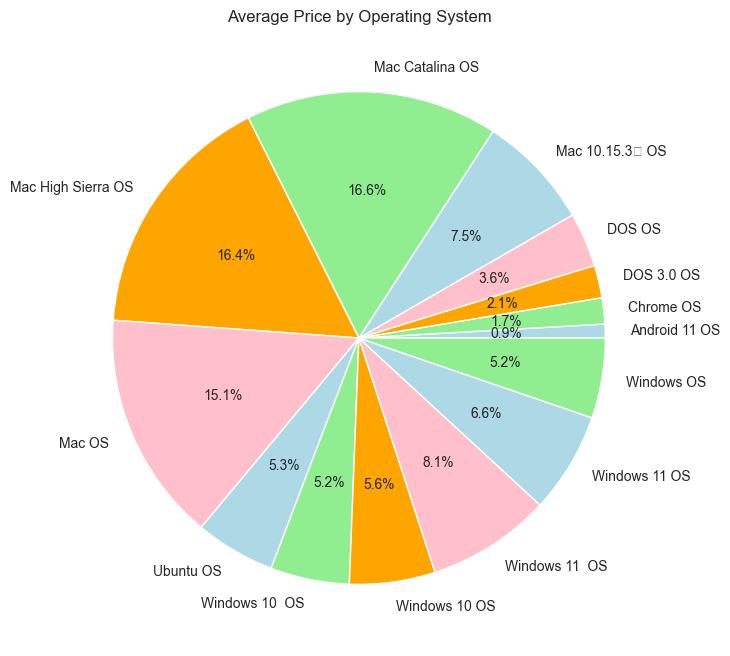

In [26]:
# 4. Average Price by OS (Pie Chart)
avg_price_os = df.groupby('OS')['price'].mean()
plt.figure(figsize=(8,8))
avg_price_os.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightgreen', 'orange', 'pink'])
plt.title('Average Price by Operating System')
plt.ylabel('')
plt.show()

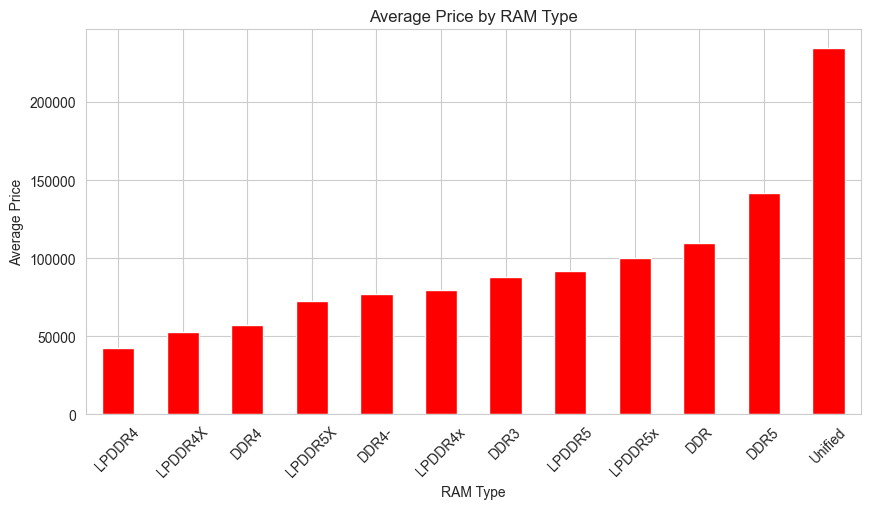

In [27]:
 # Price Comparison by RAM Type (Bar Chart)
plt.figure(figsize=(10,5))
df.groupby('Ram_type')['price'].mean().sort_values().plot(kind='bar', color='red')
plt.title('Average Price by RAM Type')
plt.xlabel('RAM Type')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


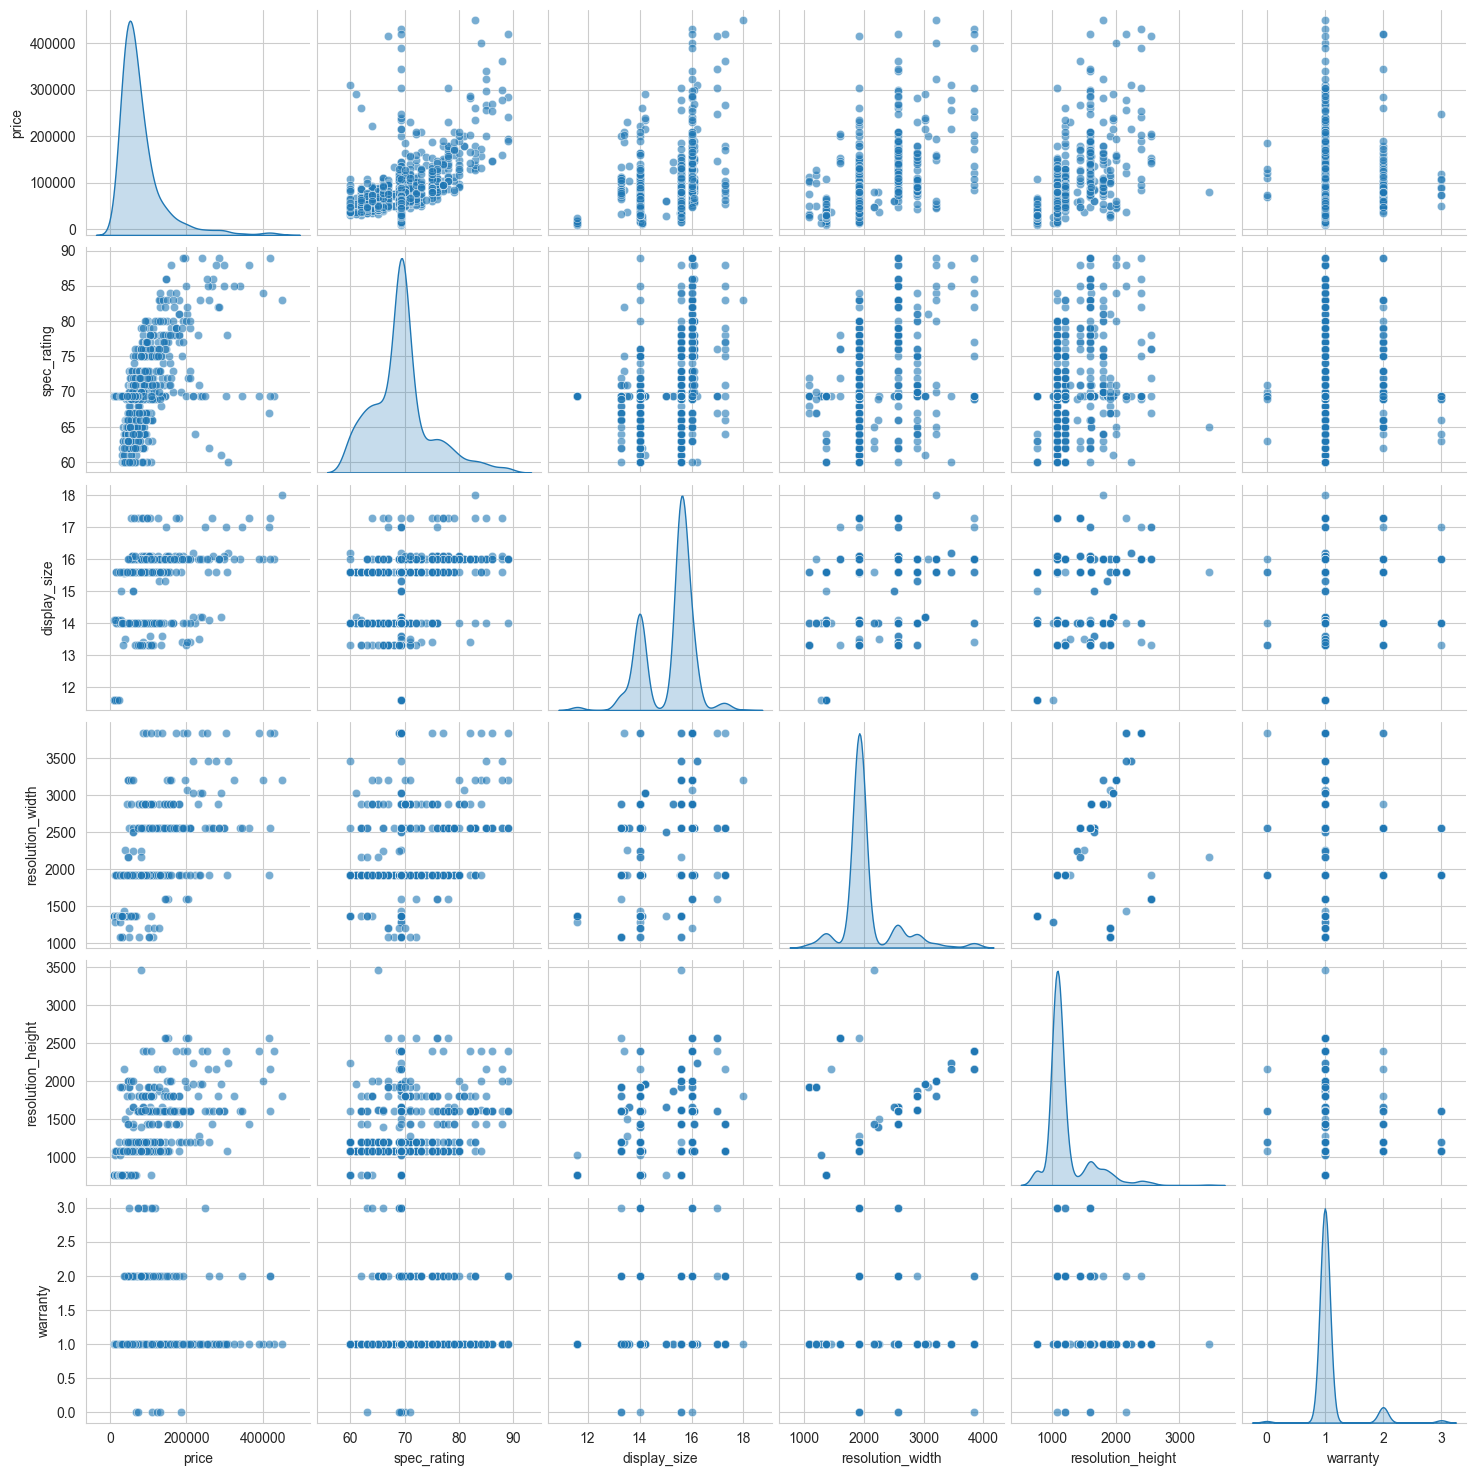

In [28]:
sns.pairplot(df.select_dtypes(include=['float64', 'int64']), diag_kind='kde', plot_kws={'alpha':0.6})
plt.show()

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


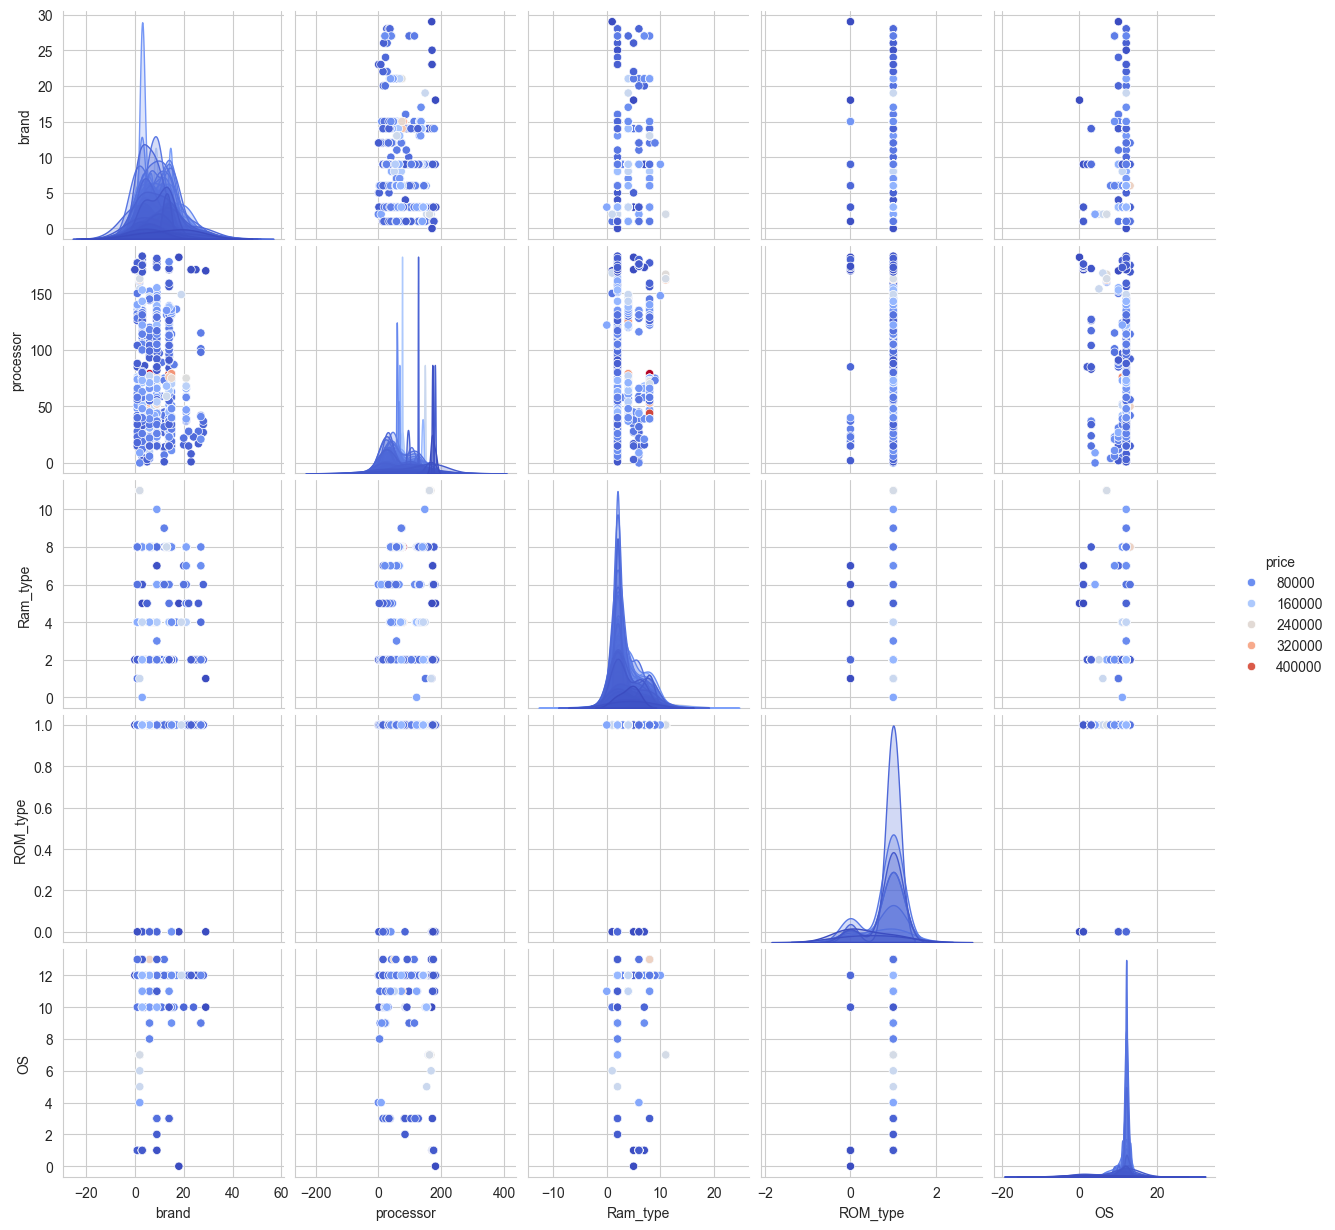

In [29]:
# 9. Pairplot for Categorical Features (Converted to Numerical)
categorical_features = ['brand', 'processor', 'Ram_type', 'ROM_type', 'OS']
df_encoded = df.copy()
for col in categorical_features:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

sns.pairplot(df_encoded, vars=categorical_features, hue='price', palette='coolwarm')
plt.show()

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              893 non-null    object 
 1   name               893 non-null    object 
 2   price              893 non-null    int64  
 3   spec_rating        893 non-null    float64
 4   processor          893 non-null    object 
 5   CPU                893 non-null    object 
 6   Ram                893 non-null    object 
 7   Ram_type           893 non-null    object 
 8   ROM                893 non-null    object 
 9   ROM_type           893 non-null    object 
 10  GPU                893 non-null    object 
 11  display_size       893 non-null    float64
 12  resolution_width   893 non-null    float64
 13  resolution_height  893 non-null    float64
 14  OS                 893 non-null    object 
 15  warranty           893 non-null    int64  
dtypes: float64(4), int64(2), o

# Visualixation using plotly subplots

In [31]:
import pandas as pd
import plotly.express as px
import plotly.subplots as sp
from plotly.graph_objects import Figure

# Define numerical and categorical columns
numerical_cols = ["price", "spec_rating", "display_size", "resolution_width", "resolution_height", "warranty"]
categorical_cols = ["brand", "processor", "CPU", "Ram", "Ram_type", "ROM", "ROM_type", "GPU", "OS"]

# Define grid layout (adjust rows & cols for better spacing)
num_plots = len(numerical_cols) + len(categorical_cols)
cols = 3  # Number of columns in grid
rows = (num_plots // cols) + (num_plots % cols > 0)  # Calculate required rows

# Create a subplot figure with a grid
fig = sp.make_subplots(
    rows=rows, cols=cols, 
    subplot_titles=numerical_cols + categorical_cols, 
    horizontal_spacing=0.15, vertical_spacing=0.2
)

# Track current position in grid
plot_index = 0

# Add numerical plots (histograms)
for col in numerical_cols:
    row = (plot_index // cols) + 1
    col_pos = (plot_index % cols) + 1
    hist_fig = px.histogram(df, x=col)
    for trace in hist_fig.data:
        fig.add_trace(trace, row=row, col=col_pos)
    plot_index += 1

# Add categorical plots (bar charts)
for col in categorical_cols:
    row = (plot_index // cols) + 1
    col_pos = (plot_index % cols) + 1
    cat_counts = df[col].value_counts().reset_index()
    cat_counts.columns = [col, "count"]

    bar_fig = px.bar(cat_counts, x=col, y="count")
    for trace in bar_fig.data:
        fig.add_trace(trace, row=row, col=col_pos)
    plot_index += 1

# Update layout
fig.update_layout(
    height=3000, width=1500, title_text="Subplots of Dataset Features (Grid Layout)", 
    showlegend=False
)

fig.show()


In [32]:
# Select important categorical columns
important_categorical_cols = ["brand", "processor", "CPU", "Ram", "Ram_type", "ROM", "GPU", "OS"]

# Loop through the columns and display grouped counts
for col in important_categorical_cols:
    print(f"\n📌 **{col} - Value Counts (Sorted)**")
    print(df[col].value_counts().sort_values(ascending=False))
    print("-" * 50)


📌 **brand - Value Counts (Sorted)**
brand
HP           186
Lenovo       169
Asus         157
Dell         107
Acer          84
MSI           65
Samsung       28
Apple         16
Infinix       15
LG             9
Xiaomi         8
Gigabyte       8
Fujitsu        6
Zebronics      4
Ultimus        4
Chuwi          3
Realme         3
Tecno          3
Wings          3
Microsoft      2
AXL            2
Huawei         2
Honor          2
Walker         1
Vaio           1
Avita          1
Primebook      1
Ninkear        1
Razer          1
iBall          1
Name: count, dtype: int64
--------------------------------------------------

📌 **processor - Value Counts (Sorted)**
processor
12th Gen Intel Core i5 1235U      49
13th Gen Intel Core i5 1335U      41
12th Gen Intel Core i3 1215U      38
11th Gen Intel Core i3 1115G4     36
12th Gen Intel Core i5 12450H     33
                                  ..
11th Gen Intel Core i7 1165G7      1
Intel Pentium Silver N6000         1
13th Gen Intel 7 13700H

# Outliers

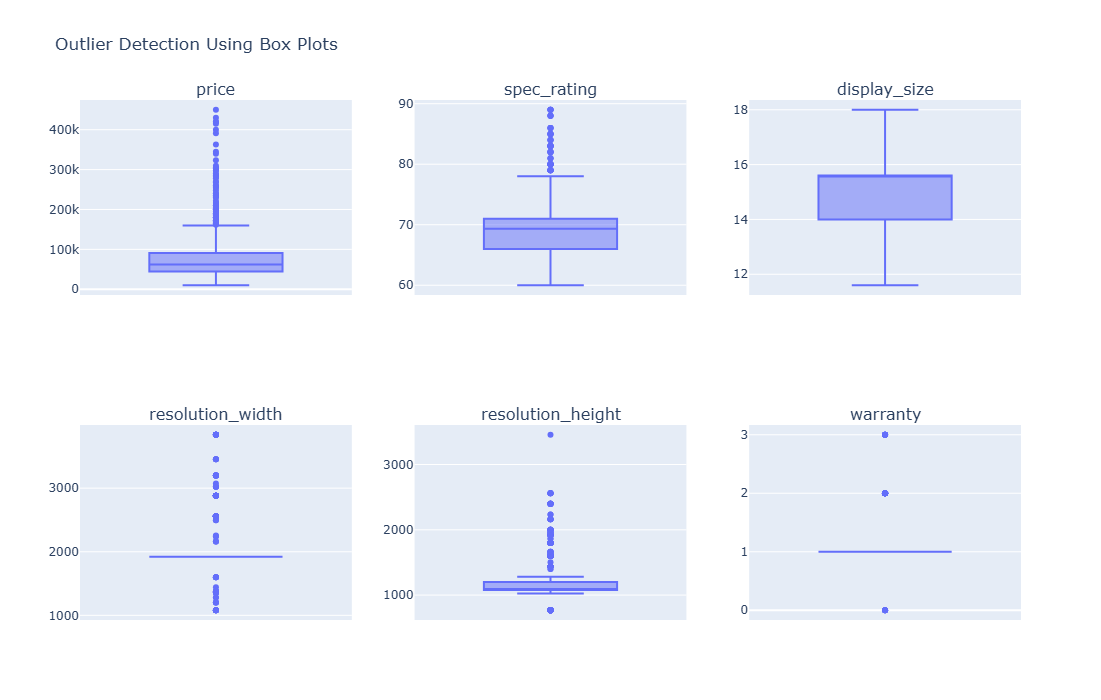

In [33]:
# Selecting only numerical columns
numerical_cols = ["price", "spec_rating", "display_size", "resolution_width", "resolution_height", "warranty"]

# Creating subplots
fig = sp.make_subplots(rows=2, cols=3, subplot_titles=numerical_cols)

# Adding box plots for each numerical column
for i, col in enumerate(numerical_cols):
    fig.add_trace(
        px.box(df, y=col).data[0],  # Box plot for each column
        row=(i // 3) + 1,  # Row position in grid
        col=(i % 3) + 1    # Column position in grid
    )

# Update layout
fig.update_layout(height=700, width=1000, title_text="Outlier Detection Using Box Plots", showlegend=False)
fig.show()

In [35]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              893 non-null    object 
 1   name               893 non-null    object 
 2   price              893 non-null    int64  
 3   spec_rating        893 non-null    float64
 4   processor          893 non-null    object 
 5   CPU                893 non-null    object 
 6   Ram                893 non-null    object 
 7   Ram_type           893 non-null    object 
 8   ROM                893 non-null    object 
 9   ROM_type           893 non-null    object 
 10  GPU                893 non-null    object 
 11  display_size       893 non-null    float64
 12  resolution_width   893 non-null    float64
 13  resolution_height  893 non-null    float64
 14  OS                 893 non-null    object 
 15  warranty           893 non-null    int64  
dtypes: float64(4), int64(2), o

In [40]:
from sklearn.preprocessing import LabelEncoder



In [42]:
le=LabelEncoder()
for i in df.columns:
    if (df[i].dtype=='O'):
        df[i]=le.fit_transform(df[i])

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              893 non-null    int32  
 1   name               893 non-null    int32  
 2   price              893 non-null    int64  
 3   spec_rating        893 non-null    float64
 4   processor          893 non-null    int32  
 5   CPU                893 non-null    int32  
 6   Ram                893 non-null    int32  
 7   Ram_type           893 non-null    int32  
 8   ROM                893 non-null    int32  
 9   ROM_type           893 non-null    int32  
 10  GPU                893 non-null    int32  
 11  display_size       893 non-null    float64
 12  resolution_width   893 non-null    float64
 13  resolution_height  893 non-null    float64
 14  OS                 893 non-null    int32  
 15  warranty           893 non-null    int64  
dtypes: float64(4), int32(10), 

In [45]:
corr=df.corr()
corr

,brand,name,price,spec_rating,processor,CPU,Ram,Ram_type,ROM,ROM_type,GPU,display_size,resolution_width,resolution_height,OS,warranty
brand,1.000000,-0.175288,0.002070,0.012815,-0.116835,0.028648,-0.016704,0.042328,0.038961,-0.013511,0.128850,-0.006917,-0.037181,0.079013,0.010516,0.193965
name,-0.175288,1.000000,0.077481,0.044418,0.020635,-0.009828,-0.166662,-0.128847,-0.026606,0.080930,-0.138668,0.000874,0.212713,0.149956,0.068312,-0.038912
price,0.002070,0.077481,1.000000,0.546391,0.064416,-0.273260,-0.334575,0.267315,-0.411823,0.105690,-0.324344,0.233815,0.586042,0.604748,0.066910,0.117101
spec_rating,0.012815,0.044418,0.546391,1.000000,0.129564,-0.081725,-0.213108,0.082422,-0.357099,0.025886,-0.289573,0.274206,0.337649,0.328525,0.044449,0.109501
processor,-0.116835,0.020635,0.064416,0.129564,1.000000,0.269249,-0.046482,0.192224,-0.111719,-0.002354,-0.250043,-0.081741,0.045215,0.033436,-0.186499,-0.092352
CPU,0.028648,-0.009828,-0.273260,-0.081725,0.269249,1.000000,0.185498,-0.166491,0.130331,-0.057584,-0.226350,0.002133,-0.160937,-0.165605,-0.068898,-0.059756
Ram,-0.016704,-0.166662,-0.334575,-0.213108,-0.046482,0.185498,1.000000,-0.177580,0.168117,-0.061324,0.167183,-0.012948,-0.244925,-0.263754,-0.180160,-0.067345
Ram_type,0.042328,-0.128847,0.267315,0.082422,0.192224,-0.166491,-0.177580,1.000000,-0.143354,0.042199,0.097974,-0.179637,0.220439,0.348553,-0.018830,0.009313
ROM,0.038961,-0.026606,-0.411823,-0.357099,-0.111719,0.130331,0.168117,-0.143354,1.000000,0.205852,0.040886,-0.072280,-0.293200,-0.287206,0.027150,-0.053236
ROM_type,-0.013511,0.080930,0.105690,0.025886,-0.002354,-0.057584,-0.061324,0.042199,0.205852,1.000000,-0.068297,0.073607,0.101228,0.102298,0.210224,0.037758


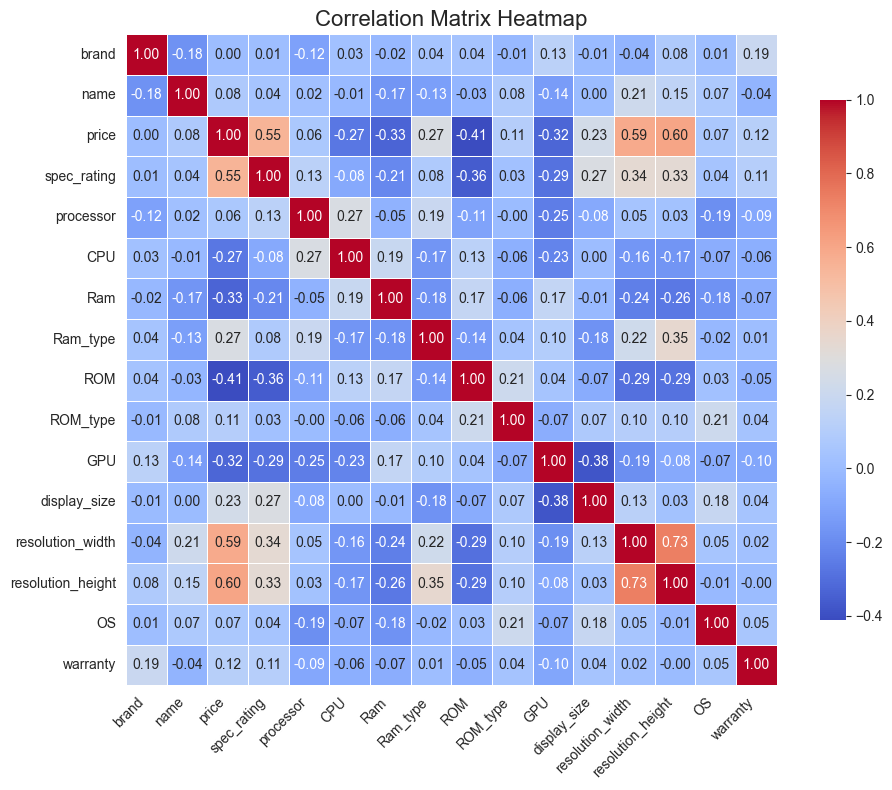

In [47]:
import seaborn as sns  
import matplotlib.pyplot as plt  

# Assuming 'corr' is your correlation matrix DataFrame  
plt.figure(figsize=(10, 8))  # Set the figure size for better visibility  
sns.heatmap(corr,   
            annot=True,         # Show the correlation values on the heatmap  
            fmt='.2f',         # Format the annotation text to 2 decimal places  
            cmap='coolwarm',   # Color map for the heatmap; you can experiment with other options like 'viridis' or 'YlGnBu'  
            square=True,       # Make each cell square-shaped  
            linewidths=0.5,    # Add lines between cells for better separation  
            cbar_kws={"shrink": .8}) # Optional: change the size of the color bar  

plt.title('Correlation Matrix Heatmap', fontsize=16)  # Add a title with larger font size  
plt.xticks(rotation=45, ha='right')  # Rotate x labels for better readability  
plt.yticks(rotation=0)  # Keep y labels horizontal  
plt.tight_layout()  # Adjust layout to make room for tick labels  
plt.show()  # Display the heatmap

In [53]:
import pandas as pd  
from sklearn.model_selection import train_test_split  
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error, r2_score  

# Assuming 'df' is your DataFrame  
# Prepare the data  
x = df.drop(columns=['price'])  # Feature set  
y = df['price']  # Target variable  

# Split the data into training and test sets  
x_train, x_test, y_train, y_test = train_test_split(x, y,   
                                                    test_size=0.2,   
                                                    random_state=42)  

# Create a Linear Regression model  
model = LinearRegression()  

# Train the model  
model.fit(x_train, y_train)  

# Make predictions on the test set  
y_pred = model.predict(x_test)  

# Evaluate the model  
mse = mean_squared_error(y_test, y_pred)  
r2 = r2_score(y_test, y_pred)  

print(f"Mean Squared Error: {mse:.2f}")  
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 961617187.19
R-squared: 0.72
